In [1]:
import os
import random
import time
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.utils.class_weight import compute_sample_weight


# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

os.environ["PYTHONHASHSEED"] = str(SEED)


print("Libraries loaded")
print("Seed fixed:", SEED)

Libraries loaded
Seed fixed: 42


In [2]:
train_data = pd.read_csv(
    r"../datasets/CICIDS2017/train_test/CICIDS2017_Train_80.csv"
)


test_data = pd.read_csv(
    r"../datasets/CICIDS2017/train_test/CICIDS2017_Test_20.csv"
)


print("Train shape:", train_data.shape)
print("Test shape :", test_data.shape)

Train shape: (1948553, 41)
Test shape : (487139, 41)


In [3]:
X_train = train_data.drop(
    "label",
    axis=1
)


X_test = test_data.drop(
    "label",
    axis=1
)


y_train = train_data["label"]

y_test = test_data["label"]


print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1948553, 40)
X_test : (487139, 40)
y_train: (1948553,)
y_test : (487139,)


In [4]:
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)


print(sample_weights[:10])

[ 0.09742707  1.07844812  0.09742707  0.09742707  0.09742707 25.36121668
  1.8173342   0.09742707  0.50080909  0.09742707]


In [5]:
lgb_model = LGBMClassifier(

    objective="multiclass",

    num_class=14,

    n_estimators=300,

    learning_rate=0.05,

    num_leaves=64,

    max_depth=-1,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=SEED,

    n_jobs=-1,

    verbosity=-1

)


print(lgb_model)

LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, n_estimators=300,
               n_jobs=-1, num_class=14, num_leaves=64, objective='multiclass',
               random_state=42, subsample=0.8, verbosity=-1)


In [6]:



lgb_model.fit(

    X_train,

    y_train,

    sample_weight=sample_weights

)

y_pred = lgb_model.predict(
    X_test
)


In [7]:
accuracy = accuracy_score(
    y_test,
    y_pred
)


precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)


recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)


f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)


print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9988278499565832
Precision: 0.9990889378050662
Recall   : 0.9988278499565832
F1 Score : 0.998924746403642


In [8]:
print(

    classification_report(

        y_test,

        y_pred,

        digits=4

    )

)

              precision    recall  f1-score   support

           0     0.9999    0.9989    0.9994    357145
           1     1.0000    1.0000    1.0000      1102
           2     0.9998    1.0000    0.9999     19147
           3     0.9911    1.0000    0.9955      1673
           4     0.9999    0.9998    0.9998     69479
           5     0.9776    0.9883    0.9830      1372
           6     0.9854    0.9787    0.9821      1035
           7     0.9995    1.0000    0.9997      1906
           8     1.0000    1.0000    1.0000         2
           9     1.0000    0.9998    0.9999     32265
          10     0.9983    1.0000    0.9992      1190
          11     0.6191    0.8647    0.7216       547
          12     0.5000    0.8000    0.6154         5
          13     0.5893    0.8155    0.6842       271

    accuracy                         0.9988    487139
   macro avg     0.9043    0.9604    0.9271    487139
weighted avg     0.9991    0.9988    0.9989    487139



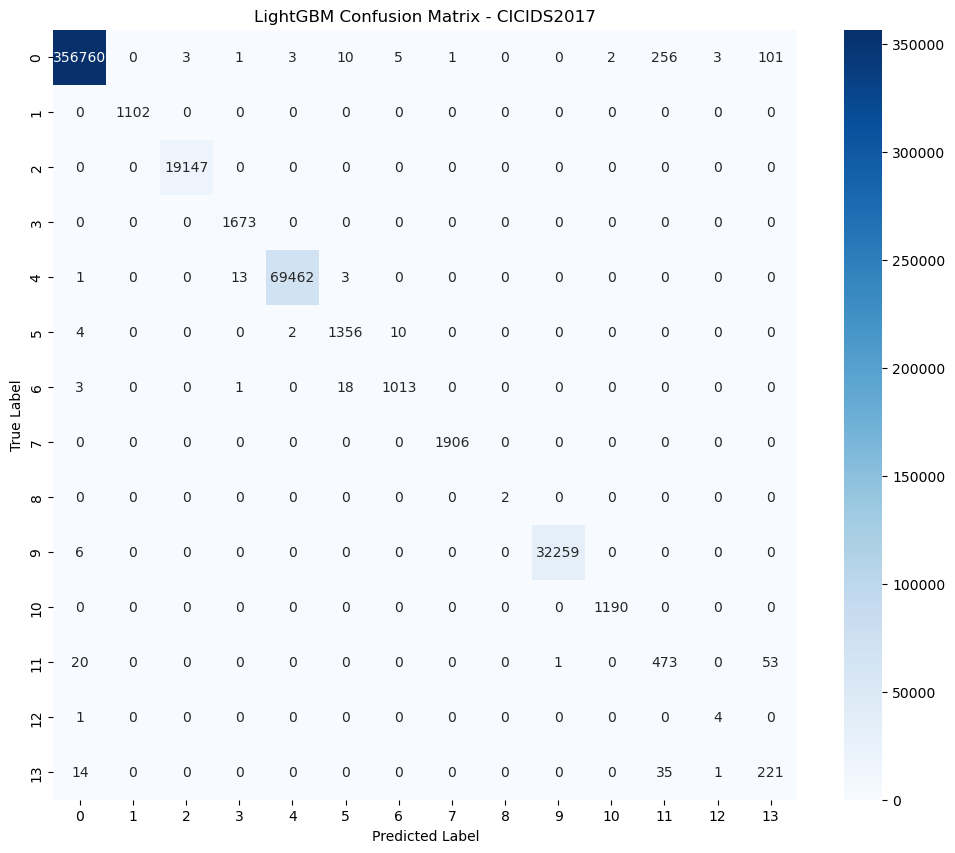

In [9]:
cm = confusion_matrix(
    y_test,
    y_pred
)


plt.figure(
    figsize=(12,10)
)


sns.heatmap(

    cm,

    cmap="Blues",
    annot=True,

    fmt="d"

)


plt.xlabel(
    "Predicted Label"
)


plt.ylabel(
    "True Label"
)


plt.title(
    "LightGBM Confusion Matrix - CICIDS2017"
)


plt.show()

In [10]:
joblib.dump(

    lgb_model,

    "LightGBM_CICIDS2017.pkl"

)


print("LightGBM model saved")

LightGBM model saved


In [11]:
lgb_results = pd.DataFrame({

    "Model": [
        "LightGBM"
    ],

    "Accuracy": [
        accuracy
    ],

    "Precision": [
        precision
    ],

    "Recall": [
        recall
    ],

    "F1_Score": [
        f1
    ],

    

})


lgb_results.to_csv(
    "LightGBM_results.csv",
    index=False
)


print(lgb_results)

      Model  Accuracy  Precision    Recall  F1_Score
0  LightGBM  0.998828   0.999089  0.998828  0.998925


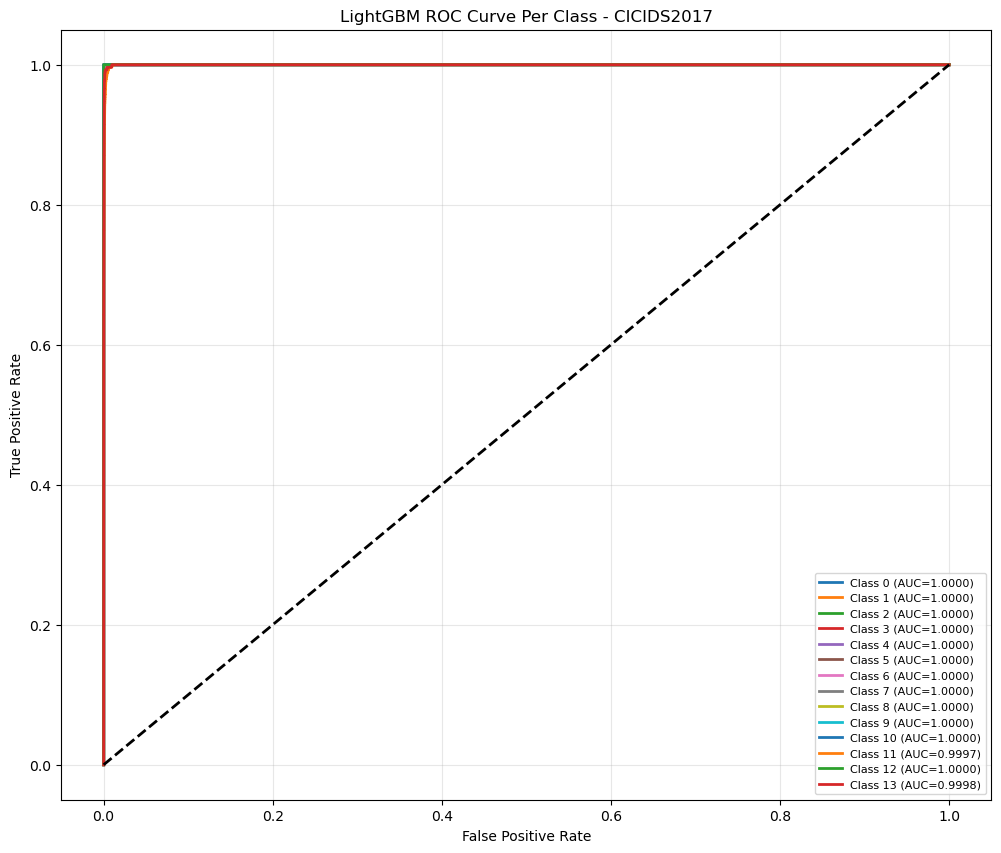

In [12]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Probability prediction for ROC
y_score = lgb_model.predict_proba(X_test)

# Convert labels to binary format
classes = np.unique(y_test)

y_test_bin = label_binarize(
    y_test,
    classes=classes
)

n_classes = len(classes)

# Plot ROC per class
plt.figure(figsize=(12, 10))

for i in range(n_classes):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"Class {classes[i]} (AUC={roc_auc:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    "k--",
    linewidth=2
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "LightGBM ROC Curve Per Class - CICIDS2017"
)

plt.legend(
    loc="lower right",
    fontsize=8
)

plt.grid(alpha=0.3)

plt.show()